 # Semi-supervised CITE-seq analysis with TotalANVI                                                                                                             
  With TotalANVI, we can perform semi-supervised analysis of CITE-seq data by leveraging partial cell type annotations to jointly model RNA and protein. Starting from a pretrained totalVI model, TotalANVI fine-tunes the latent space to predict cell type labels for unannotated cells, impute missing protein measurements, and perform differential abundance analysis. Here we demonstrate this functionality with an immune aging CITE-seq dataset spanning multiple tissues and donors, measured across two protein panels.                                                                                   

In [1]:
!pip install --quiet scvi-colab
from scvi_colab import install

install()


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi_colab/_core.py:42: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import ContextualVersionConflict
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi_colab/_core.py:47: UserWarning: 
                Not currently in Google Colab environment.

                Please run with `run_outside_colab=True` to override.

                Returning with no further action.
                
  warn(


## Imports

In [12]:
import os
import tempfile
import time

import anndata as ad
import matplotlib.pyplot as plt
import mudata as md
import muon
import numpy as np
import pandas as pd
import rapids_singlecell as rsc
import requests
import scanpy as sc
import scvi
import seaborn as sns
import torch
from scib_metrics.benchmark import BatchCorrection, Benchmarker, BioConservation
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

In [6]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.4.3


In [7]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

## Load mudata, Setup mudata and train totalANVI

For this tutorial, we use data from the following source: DOI: 10.1038/s41590-025-02241-4, an open-source multimodal CITE-seq and RNA dataset with two protein panels, generated using 10x Genomics technology. We demonstrate TotalANVI for protein imputation and T cells type prediction by randomly masking protein data in 40% of cells with real protein measurements and setting their cell type labels to “unlabeled” (celltypes_mask), then evaluating the imputed values against the held-out ground truth.

For evaluation we train three complementary models on the same dataset:
- totalANVI : multimodal (RNA + protein) semi-supervised
- totalVI   : multimodal (RNA + protein) unsupervised
- scANVI    : RNA-only semi-supervised (for comparison)
- scVI       : RNA-only unsupervised (for comparison)


In [10]:
mdata_path = os.path.join(save_dir.name, "immune_aging_cd.h5mu")

# direct download URL
url = "https://exampledata.scverse.org/scvi-tools/immune_aging_cd.h5mu"

# Download only if file doesn't already exist
if not os.path.exists(mdata_path):
    print(f"Downloading MuData file to {mdata_path}...")
    r = requests.get(url)
    with open(mdata_path, "wb") as f:
        f.write(r.content)

# Load the MuData object
mdata = muon.read_h5mu(mdata_path)

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_

In [13]:
mdata

MuData object with n_obs × n_vars = 553449 × 35010
  2 modalities
    rna:	553449 x 34741
      obs:	'site', 'tissue', 'celltype', 'sample', 'chemistry', 'donor_tissue', 'cmv', 'ebv', 'EBV', 'CMV', 'celltypes_mask', 'protein_panel_mask', 'sample_id', 'donor', 'protein_panel', 'protein_panel_site'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'hsp', 'is_highly_variable_gene_batch_key_donor_id', 'is_highly_variable_gene_batch_key_donor_id+tissue', 'gene_name'
      obsm:	'celltypist', 'celltypist_probability_matrix.Immune_All_High', 'celltypist_probability_matrix.Immune_All_Low', 'protein_expression', 'protein_expression_Ctrl', 'protein_expression_mask', 'protein_totalanvi', 'protein_totalanvi_mask'
    prot:	553449 x 269
      obs:	'site', 'tissue', 'celltype', 'sample', 'chemistry', 'donor_tissue', 'cmv', 'ebv', 'EBV', 'CMV', 'celltypes_mask', 'protein_panel_mask', 'sample_id', 'donor', 'protein_panel', 'protein_panel_site'
      obsm:	'protein_masked', 'protein_original'

The masked protein data used as model input is stored in mdata['prot'].X, while the original ground-truth protein values are preserved in mdata['prot'].obsm['protein_original'].
The obs column protein_panel_mask indicates which cells belong to the masked evaluation set
The corresponding cell type labels were replaced with "unlabeled" in celltypes_mask to evaluate semi-supervised cell type prediction (original cell types in "celltype").

In [14]:
# Evaluate the number of cells with protein values after masking

prot2 = np.array(mdata["prot"].X)  # prot_X_masked is stored as X in prot_adata
has_prot2 = prot2.sum(axis=1) > 0

print(f"Has protein (masked input):   {has_prot2.sum():,}  ({has_prot2.mean() * 100:.2f}%)")
print(f"No protein  (masked input):   {(~has_prot2).sum():,}  ({(~has_prot2).mean() * 100:.2f}%)")
print(f"Total:                        {len(mdata['prot']):,}")

# Cross check with protein_panel_mask
print("\n=== mdata prot.X × protein_panel_mask ===")
print(
    pd.crosstab(
        mdata["prot"].obs["protein_panel_mask"],  # protein_na_UK/protein_panel_mask
        pd.Series(has_prot2, index=mdata["prot"].obs.index, name="has_protein"),
        margins=True,
    )
)

Has protein (masked input):   327,336  (59.14%)
No protein  (masked input):   226,113  (40.86%)
Total:                        553,449

=== mdata prot.X × protein_panel_mask ===
has_protein          False    True     All
protein_panel_mask                        
panel_0             226071       0  226071
panel_1                 42  274932  274974
panel_2                  0   52404   52404
All                 226113  327336  553449


In [15]:
# Evaluate the number of cells with celltype lables after masking

n_cells = len(mdata.obs)

print(f"\n=== Cell Statistics (n={n_cells:,}) ===")

# --- Celltype masked ---
n_unlabeled = (mdata["prot"].obs["celltypes_mask"] == "unlabeled").sum()  # celltypes_mask
n_labeled = (mdata["prot"].obs["celltypes_mask"] != "unlabeled").sum()  # celltype_unlabeled_UK
print("\n--- Celltype (masked) ---")
print(f"  Labeled:    {n_labeled:>7,}  ({n_labeled / n_cells * 100:.1f}%)")
print(f"  Unlabeled:  {n_unlabeled:>7,}  ({n_unlabeled / n_cells * 100:.1f}%)")


=== Cell Statistics (n=553,449) ===

--- Celltype (masked) ---
  Labeled:    335,280  (60.6%)
  Unlabeled:  218,169  (39.4%)


### Prepare multimodal data for TotalVI/TOTALANVI training

In [16]:
mdata_cd = mdata[mdata.obs["rna:celltype"].str.lower().str.startswith("cd")].copy()
sub = mdata_cd["rna"].copy()
sub.layers["counts"] = sub.X.copy()
prot_sub = mdata_cd["prot"][sub.obs_names].copy()

sub.obsm["protein_totalanvi_mask"] = prot_sub.X.copy()
sub.obs["protein_panel_mask"] = prot_sub.obs["protein_panel_mask"].copy()
sub.obs["celltypes_mask"] = prot_sub.obs["celltypes_mask"].copy()

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_

In [18]:
sc.pp.highly_variable_genes(sub, n_top_genes=6000, subset=True, layer="counts", flavor="seurat_v3")

In [19]:
sub_sub = sub[sub.obs["protein_panel_mask"] == "panel_0"].copy()
sub_sub.obs["protein_panel_mask"] = "panel_0_copy"
sub_sub.obs["donor_tissue"] = sub_sub.obs["donor_tissue"].astype(str) + "_no_protein"
sub_sub.obsm["protein_totalanvi_mask"] = 0.0 * sub_sub.obsm["protein_totalanvi_mask"]
sub_sub.obs_names = sub_sub.obs_names + "_no_protein"

sub_concat = ad.concat([sub, sub_sub])

prot_concat = ad.AnnData(
    X=sub_concat.obsm["protein_totalanvi_mask"],
    obs=sub_concat.obs.copy(),
    var=mdata_cd["prot"].var.copy(),
)
prot_concat.obs_names = sub_concat.obs_names.copy()

In [20]:
original_mask = ~sub_concat.obs_names.str.endswith("_no_protein")
prot_concat.obsm["protein_original"] = np.zeros(
    (len(sub_concat), mdata_cd["prot"].obsm["protein_original"].shape[1]), dtype=np.float32
)
prot_concat.obsm["protein_original"][original_mask] = mdata_cd["prot"][sub.obs_names].obsm[
    "protein_original"
]

mdata_concat = md.MuData({"rna": sub_concat, "prot": prot_concat})

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_

train TOTALVI, add the panel_key argument to setup_mudata to enable panel-specific batch effect correction and imputation, which is important for the masked protein setting in this dataset.

In [21]:
scvi.model.TOTALVI.setup_mudata(
    mdata_concat,
    rna_layer="counts",
    protein_layer=None,
    batch_key="donor_tissue",
    panel_key="protein_panel_mask",  # add here
    modalities={
        "rna_layer": "rna",
        "protein_layer": "prot",
        "batch_key": "rna",
        "panel_key": "rna",
    },
)

INFO     Found batches with missing protein expression                                                             


In [22]:
early_stopping_kwargs = {
    "early_stopping": True,
    "early_stopping_monitor": "elbo_validation",
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 1.0,
    "check_val_every_n_epoch": 1,
}

In [23]:
totalvi = scvi.model.TOTALVI(
    mdata_concat,
    empirical_protein_background_prior=False,
    dropout_rate_decoder=0.03,
    encode_covariates=True,
)

/tmp/ipykernel_2781906/3901187311.py:1: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
  totalvi = scvi.model.TOTALVI(


In [25]:
totalvi.train(
    batch_size=1024,
    max_epochs=200,
    train_size=0.9,
    adversarial_classifier=True,
    lr=3e-3,
    n_epochs_kl_warmup=20,
    plan_kwargs={"pro_recons_weight": 0.3},
    **early_stopping_kwargs,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which 

Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 1554.683. Signaling Trainer to stop.


Observe the training and validation ELBO curves to check for convergence and potential overfitting. The early stopping criteria will help prevent overfitting by monitoring the validation ELBO and stopping training if it does not improve for a certain number of epochs (patience).

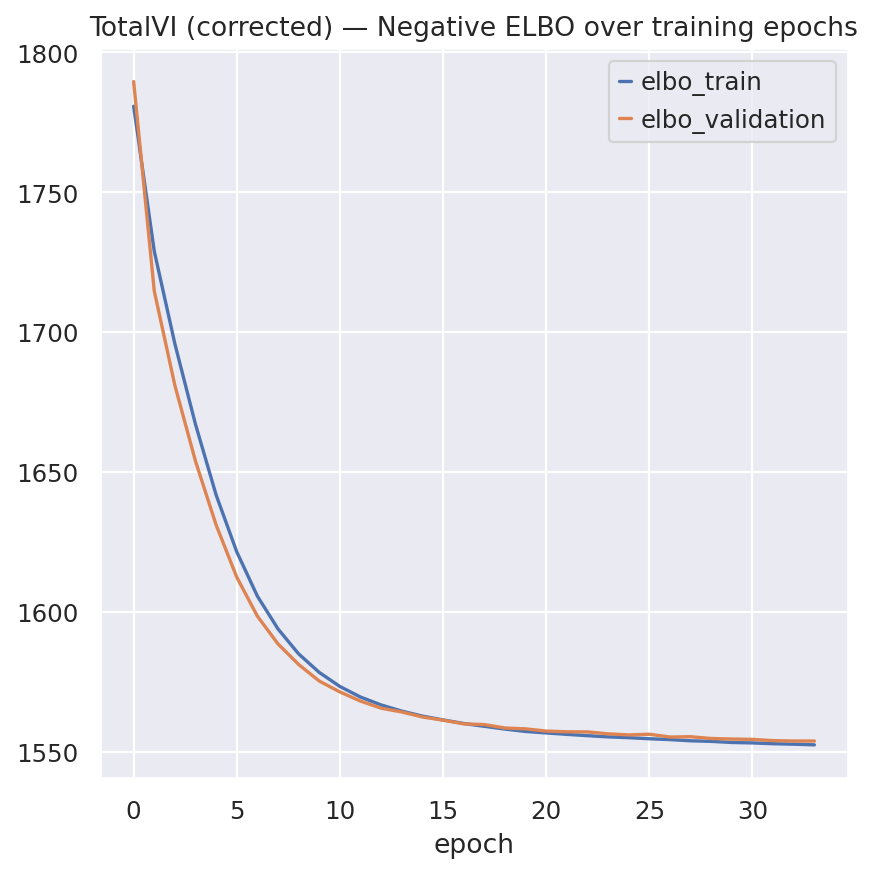

In [26]:
fig, ax = plt.subplots(1, 1)
totalvi.history["elbo_train"].plot(ax=ax, label="train")
totalvi.history["elbo_validation"].plot(ax=ax, label="validation")
ax.set(title="TotalVI (corrected) — Negative ELBO over training epochs")
ax.legend()

add latent representation and imputed protein expression to obsm for downstream analysis and evaluation

In [ ]:
mdata_concat.obsm["X_totalVI"] = totalvi.get_latent_representation()
mdata_concat.mod["rna"].obsm["X_totalVI"] = mdata_concat.obsm["X_totalVI"]

Well define a helper function to help us extract the protein information for imputation

In [ ]:
def extract_protein_prediction(mdata, model, model_name, n_samples=25, gene_list=None):
    """Extract normalized protein expression and foreground probability from model into MuData.

    Parameters
    ----------
    mdata      : MuData object
    model      : trained totalVI or totalANVI model
    model_name : str, prefix for layer/obsm keys (e.g. 'totalanvi', 'totalvi')
    n_samples  : int, number of samples for Monte Carlo estimation
    gene_list  : list, gene to condition on (required by the model)
    """
    if gene_list is None:
        gene_list = ["ISG15"]
    # Get normalized protein expression (foreground only)
    _, protein = model.get_normalized_expression(
        n_samples=n_samples,
        include_protein_background=False,
        gene_list=gene_list,
    )

    # Get foreground probability
    foreground_prob = model.get_protein_foreground_probability(
        n_samples=n_samples,
    )

    # Store in prot layers
    mdata.mod["prot"].layers[f"{model_name}_imputed"] = protein.values
    mdata.mod["prot"].layers[f"{model_name}_foreground_prob"] = foreground_prob.values

    # Store in obsm
    mdata.obsm[f"{model_name}_protein_imputed"] = protein.values
    mdata.obsm[f"{model_name}_protein_foreground_prob"] = foreground_prob.values

    print(f"✅ [{model_name}] stored — protein shape: {protein.shape}")

In [ ]:
extract_protein_prediction(mdata_concat, totalvi, model_name="totalvi")

*** Note *** 
 You can use `transform_batch=batches` during protein imputation  to generate predictions relative to specific donor_tissue batches. Example for the current dataset: 

batches = list(
    mdata[mdata.obs['donor'].isin(['778C', 'D523'])]
    .obs['donor_tissue'].unique())

train TOTALANVI using the trained TOTALVI model, which will leverage the semi-supervised cell type labels (with "unlabeled" category) to learn a more discriminative latent representation and potentially improve imputation and cell type prediction performance, especially for the masked protein setting in this dataset.

In [28]:
totalanvi = scvi.external.TOTALANVI.from_totalvi_model(
    totalvi,
    unlabeled_category="unlabeled",
    labels_key="celltypes_mask",
    linear_classifier=True,
)

INFO     Found batches with missing protein expression                                                             


/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/external/totalanvi/_model.py:108: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
  super().__init__(
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/external/totalanvi/_model.py:285: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
  totalanvi_model = cls(adata, **non_kwargs, **kwargs, **totalanvi_kwargs)
2026-06-21 16:45:03 | [INFO] Sample level parameters are not optimized during supervised model. This helps with integration


In [29]:
totalanvi.train(
    batch_size=1024,
    max_epochs=100,
    adversarial_classifier=False,
    early_stopping=True,
    early_stopping_monitor="elbo_validation",
    early_stopping_patience=15,
    early_stopping_min_delta=0.1,
    check_val_every_n_epoch=1,
    plan_kwargs={
        "pro_recons_weight": 0.3,
        "n_epochs_kl_warmup": 20,
        "lr": 3e-3,
        "classification_ratio": 200.0,
        "max_kl_weight": 1.0,
    },
)

INFO     Training for 100 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.

Training:   0%|          | 0/100 [00:00<?, ?it/s]

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 1024. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 129. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Monitored metric elbo_validation did not improve in the last 15 records. Best score: 1546.435. Signaling Trainer to stop.


Observe the training and validation ELBO curves to check for convergence and potential overfitting.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
totalanvi.history["elbo_train"].plot(ax=ax, label="train")
totalanvi.history["elbo_validation"].plot(ax=ax, label="validation")
ax.set_title("TotalANVI — Negative ELBO over training epochs")
ax.set_xlabel("epoch")
ax.set_ylabel("Negative ELBO")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Save the trained TotalANVI model and processed MuData for downstream analysis.
totalanvi.save(os.path.join(save_dir.name, "totalanvi"), save_anndata=True, overwrite=True)

add latent representation and imputed protein expression to obsm for downstream analysis and evaluation

In [ ]:
mdata_concat.obs["totalanvi_predicted_celltypes"] = totalanvi.predict()
mdata_concat.obsm["X_totalANVI"] = totalanvi.get_latent_representation()
mdata_concat.mod["rna"].obsm["X_totalANVI"] = mdata_concat.obsm["X_totalANVI"]
rsc.pp.neighbors(mdata_concat, use_rep="X_totalANVI", n_neighbors=30)
rsc.tl.umap(mdata_concat, min_dist=0.3)

In [ ]:
extract_protein_prediction(mdata_concat, totalanvi, model_name="totalanvi")

Remove the _no_protein cells for evaluation and downstream analysis. These cells had no protein data and were only used to improve imputation performance for the masked protein setting during training.

In [ ]:
mdataf_orig = mdata_concat[~mdata_concat.obs_names.str.endswith("_no_protein")].copy()

### Train SCANVI only on RNA data to evaluate the benefit of multimodal training in TOTALANVI.

In [ ]:
sub = mdataf_orig["rna"].copy()
sub.layers["counts"] = sub.X.copy()
scvi.model.SCVI.setup_anndata(sub, layer="counts", batch_key="donor_tissue")

Scvi = scvi.model.SCVI(
    sub,
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)

Scvi.train(batch_size=1024, max_epochs=100, check_val_every_n_epoch=1)
sub.obsm["X_scVI"] = Scvi.get_latent_representation()

In [35]:
scANVI = scvi.model.SCANVI.from_scvi_model(
    Scvi,
    unlabeled_category="unlabeled",
    labels_key="celltypes_mask",
    linear_classifier=True,
)

scANVI.train(batch_size=1024, n_samples_per_label=100, max_epochs=60, check_val_every_n_epoch=1)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


INFO     Training for 60 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.

Training:   0%|          | 0/60 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


add latent representation and predicted cell types from scANVI to obsm/obs for downstream analysis and evaluation, and compare with the results from TOTALANVI to evaluate the benefit of multimodal training in this dataset, especially in terms of learning a more discriminative latent representation and improving cell type prediction performance for the masked protein setting.

In [ ]:
sub.obsm["X_scANVI"] = scANVI.get_latent_representation()
sub.obs["scanvi_predicted_celltypes"] = scANVI.predict()

mdataf_orig = mdata_concat[~mdata_concat.obs_names.str.endswith("_no_protein")].copy()
mdataf_orig.obs["scanvi_predicted_celltypes"] = sub.obs["scanvi_predicted_celltypes"].values
mdataf_orig.obsm["X_scANVI"] = sub.obsm["X_scANVI"]
mdataf_orig.mod["rna"].obsm["X_scANVI"] = sub.obsm["X_scANVI"]
mdataf_orig.mod["rna"].obsm["X_scVI"] = sub.obsm["X_scVI"]

In [37]:
# save
mdataf_orig.write(os.path.join(save_dir.name, "mdataf_orig.h5mu"))

... storing 'totalanvi_predicted_celltypes' as categorical
... storing 'scanvi_predicted_celltypes' as categorical
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False

# Comparing integration metrics using scib-metrics package  


Compute multiple integration metrics across the scvi, scANVI, totalVI, and totalANVI embeddings to quantitatively compare biological conservation and batch integration performance. We use the scib-metrics package

In [26]:
mdata = md.read_h5mu(os.path.join(save_dir.name, "mdataf_orig.h5mu"))

/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
# Prepare AnnData for benchmarker
adata_bench = mdataf_orig.mod["rna"].copy()

# Subsample FIRST (so scib-metrics run will finish faster)
rsc.pp.subsample(adata_bench, fraction=0.2, random_state=42)
# print(f"Subsampled to: {len(adata_bench):,} cells")

#  copy embeddings, subsetting source to match subset cells
rna_sub = mdataf_orig.mod["rna"][adata_bench.obs_names]
for key in ["X_totalANVI", "X_totalVI", "X_scANVI", "X_scVI"]:
    adata_bench.obsm[key] = rna_sub.obsm[key]

In [ ]:
# Run benchmarker
biocons = BioConservation(isolated_labels=False)

custom_batch_correction = BatchCorrection(
    bras=True,
    ilisi_knn=True,
    kbet_per_label=True,
    graph_connectivity=True,
    pcr_comparison=False,
)

bm = Benchmarker(
    adata_bench,
    batch_key="donor_tissue",
    label_key="celltype",
    embedding_obsm_keys=[
        "X_totalANVI",
        "X_totalVI",
        "X_scANVI",
        "X_scVI",
    ],
    bio_conservation_metrics=biocons,
    batch_correction_metrics=custom_batch_correction,
    n_jobs=-1,
)

/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scib_metrics/benchmark/_core.py:193: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(self._adata, svd_solver=self._solver, use_highly_variable=False)
Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  25%|██▌       | 1/4 [00:54<02:44, 54.71s/it]/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. 

Benchmarking done in 3.7 min


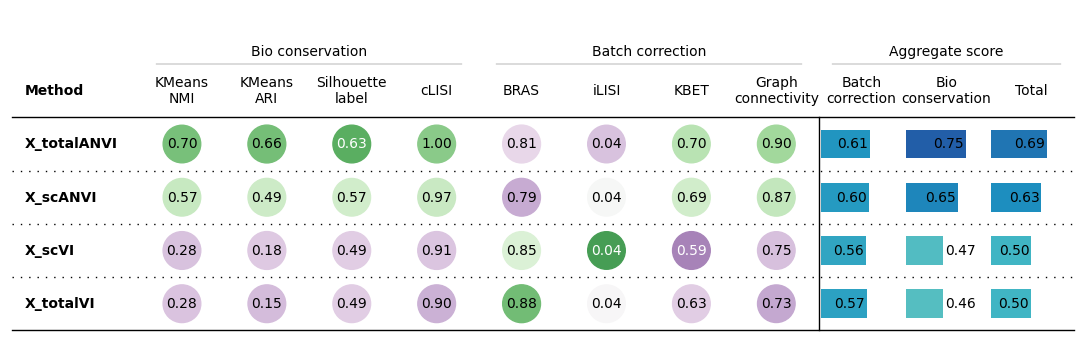

In [23]:
start = time.time()
bm.benchmark()
elapsed = time.time() - start
print(f"Benchmarking done in {elapsed / 60:.1f} min")

bm.plot_results_table(min_max_scale=False)

# Plotting confusion matrices

In [ ]:
mdata = md.read_h5mu(os.path.join(save_dir.name, "mdataf_orig.h5mu"))
mdata.mod["rna"].obs["totalanvi_predicted_celltypes"] = mdata.obs["totalanvi_predicted_celltypes"]
mdata.mod["rna"].obs["scanvi_predicted_celltypes"] = mdata.obs["scanvi_predicted_celltypes"]

obs = mdata.mod["rna"].obs
unlabeled_mask = obs["celltypes_mask"] == "unlabeled"
true_labels = obs.loc[unlabeled_mask, "celltype"]
pred_totalanvi = obs.loc[unlabeled_mask, "totalanvi_predicted_celltypes"]
pred_scanvi = obs.loc[unlabeled_mask, "scanvi_predicted_celltypes"]

# ── Confusion heatmaps ─────────────────────────────────────────────────
all_labels = sorted(true_labels.unique())
ct_totalanvi = pd.crosstab(true_labels, pred_totalanvi, normalize="index").reindex(
    index=all_labels, columns=all_labels, fill_value=0
)
ct_scanvi = pd.crosstab(true_labels, pred_scanvi, normalize="index").reindex(
    index=all_labels, columns=all_labels, fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, ct, title in zip(axes, [ct_totalanvi, ct_scanvi], ["totalANVI", "scANVI"], strict=False):
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f"{title} — held-out unlabeled cells")
    ax.set_xlabel("Predicted cell type")
    ax.set_ylabel("True cell type")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

###  Distribution divergence 
Jensen-Shannon (JS) divergence measures how much the predicted cell-type
proportions differ from the true proportions.
JS = 0 → predicted distribution is identical to the true distribution.
JS = 1 → maximum divergence (completely different distributions).
A lower JS means the model not only classifies cells correctly but also
preserves the biological composition of the sample.

In [39]:
def get_dist(series):
    counts = series.value_counts()
    return np.array([counts.get(l, 0) for l in all_labels], dtype=float) / len(series)


dist_true = get_dist(true_labels)
dist_totalanvi = get_dist(pred_totalanvi)
dist_scanvi = get_dist(pred_scanvi)

js_totalanvi = jensenshannon(dist_true, dist_totalanvi)
js_scanvi = jensenshannon(dist_true, dist_scanvi)
w_totalanvi = wasserstein_distance(
    range(len(all_labels)), range(len(all_labels)), dist_true, dist_totalanvi
)
w_scanvi = wasserstein_distance(
    range(len(all_labels)), range(len(all_labels)), dist_true, dist_scanvi
)

print(
    f"Jensen-Shannon divergence — totalANVI : {js_totalanvi:.4f}  (0=identical, 1=max divergence)"
)
print(f"Jensen-Shannon divergence — scANVI    : {js_scanvi:.4f}")
print(f"Wasserstein distance      — totalANVI : {w_totalanvi:.4f}")
print(f"Wasserstein distance      — scANVI    : {w_scanvi:.4f}")

NameError: name 'true_labels' is not defined

In [ ]:
# ── Distribution bar plots ─────────────────────────────────────────────
x, width = np.arange(len(all_labels)), 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, dist_pred, model_name, js in zip(
    axes,
    [dist_totalanvi, dist_scanvi],
    ["totalANVI", "scANVI"],
    [js_totalanvi, js_scanvi],
    strict=False,
):
    ax.bar(x - width / 2, dist_true, width, label="True", color="steelblue")
    ax.bar(x + width / 2, dist_pred, width, label=model_name, color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right")
    ax.set_title(
        f"{model_name} — predicted vs true distribution\n"
        f"JS divergence = {js:.4f}  (0=identical, 1=max)"
    )
    ax.set_ylabel("Proportion of cells")
    ax.set_xlabel("Cell type")
    ax.legend()
plt.tight_layout()
plt.show()

# Visualizing the embeddings and denoised protein values  

/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.


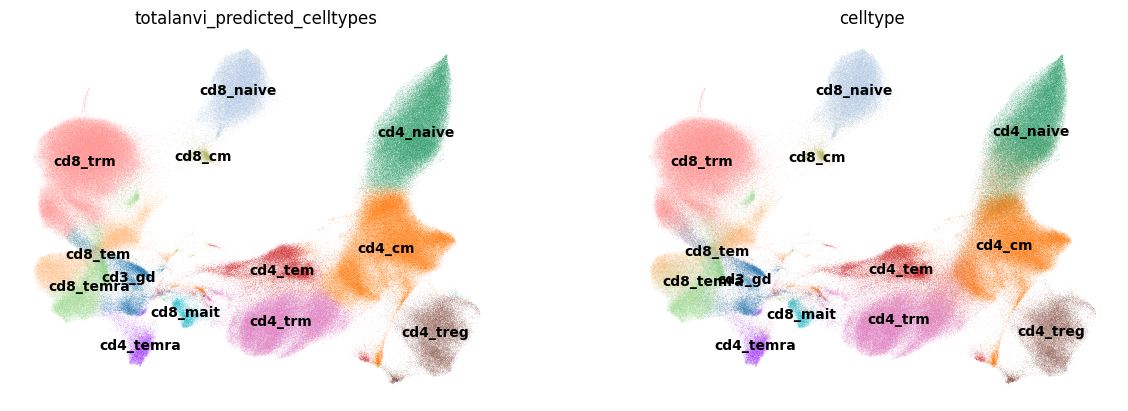

/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.


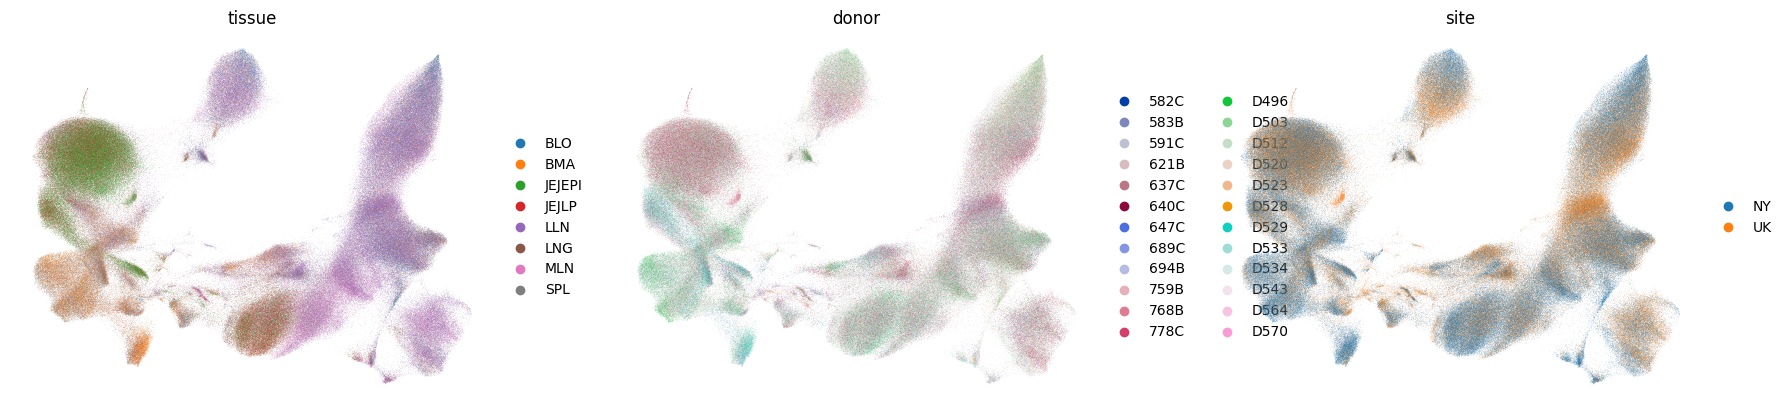

In [15]:
mdata = md.read_h5mu(os.path.join(save_dir.name, "mdataf_orig.h5mu"))

for col in mdata.mod["rna"].obs.columns:
    if col not in mdata.obs.columns:
        mdata.obs[col] = mdata.mod["rna"].obs[col].values

sc.pl.umap(
    mdata, color=["totalanvi_predicted_celltypes", "celltype"], legend_loc="on data", frameon=False
)

sc.pl.umap(mdata, color=["tissue", "donor", "site"], vmax="p98", frameon=False)

Plot UMAP colored by imputed protein expression and foreground probability for selected proteins, which are important markers for T cell subtypes and states in this dataset.
This visualization can help us qualitatively assess the imputation performance of TOTALANVI and see if the imputed protein expression patterns align with known biology, especially for the masked proteins in the evaluation set.

In [ ]:
mdata.mod["rna"].obsm["X_umap"] = mdata.obsm["X_umap"]
mdata.mod["prot"].obsm["X_umap"] = mdata.obsm["X_umap"]

proteins_to_plot = [
    "TCR_alpha/beta",
    "CD2",
    "CD4",
    "CD8",
    "CD62L",
    "CD45RA",
    "CD69",
    "KLRG1 (MAFA)",
    "CD103 (Integrin _E)",
    "CD49a",
]

In [ ]:
# Plot imputed protein expression
muon.pl.embedding(
    mdata,
    basis="prot:X_umap",
    color=["prot:" + p for p in proteins_to_plot],
    frameon=False,
    ncols=3,
    vmax="p99",
    wspace=0.1,
    layer="totalanvi_imputed",
    title=[f"{p}\n(imputed)" for p in proteins_to_plot],
    cmap="hot",
)

In [ ]:
# Plot foreground probability
muon.pl.embedding(
    mdata,
    basis="prot:X_umap",
    color=["prot:" + p for p in proteins_to_plot],
    frameon=False,
    ncols=3,
    vmax="p99",
    wspace=0.1,
    layer="totalanvi_foreground_prob",
    title=[f"{p}\n(foreground prob)" for p in proteins_to_plot],
    cmap="RdYlGn",  # green=foreground, red=background
)

### Differential Abundance Analysis: CMV+ vs CMV −

In [ ]:
totalanvi_model = scvi.external.TOTALANVI.load(os.path.join(save_dir.name, "totalanvi"))
mdata = md.read_h5mu(os.path.join(save_dir.name, "mdataf_orig.h5mu"))

INFO     File /home/michalma/AWS/TotalNVI_method/For_WebSCVI/totalanvi/model.pt already downloaded                 


/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/michalma/scvi-tools-ori/src/scvi/mod

INFO     Found batches with missing protein expression                                                             
INFO     Found batches with missing protein expression                                                             


/home/michalma/scvi-tools-ori/src/scvi/external/totalanvi/_model.py:108: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
/home/michalma/scvi-tools-ori/src/scvi/model/base/_save_load.py:158: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
/home/michalma/scvi-tools-ori/src/scvi/model/base/_base_model.py:940: FutureWarning: The method mod_names is deprecated and will be removed in the future. Use `mod.keys()` instead.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull ob

In [67]:
# filter to confirmed CMV status only
mdata_cmv = mdata[mdata.mod["rna"].obs["cmv"].isin(["positive", "negative"])].copy()
mdata_cmv.obs["cmv"] = mdata_cmv.mod["rna"].obs["cmv"]
mdata_cmv.obs["celltype"] = mdata_cmv.mod["rna"].obs["celltype"]
mdata_cmv.obs["donor"] = mdata_cmv.mod["rna"].obs["donor"]
mdata_cmv.obs["tissue"] = mdata_cmv.mod["rna"].obs["tissue"]
print(mdata_cmv.obs["cmv"].value_counts(dropna=False))

/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
/home/michalma/.conda/envs/totalNVI6/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


cmv
positive    341344
negative     87636
Name: count, dtype: int64


In [74]:
# Propagate 'tissue' (and any other keys you need) to top-level mudata.obs
# Now call differential_abundance
da_results = totalanvi_model.differential_abundance(
    adata=mdata_cmv, sample_key="cmv", batch_size=256, num_cells_posterior=2000, dof=3.0
)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Found batches with missing protein expression                                                             
INFO     Found batches with missing protein expression                                                             


100%|██████████| 2/2 [00:01<00:00,  1.06it/s]


In [77]:
# the results are in the obsm of the MuData object, which can be accessed as follows:
mdata_cmv.obsm["da_log_probs"]

,negative,positive
TTGGCAATCTAACTGG-1_CZINY-0341-4,-27.605490,-23.258560
GCCAAATGTGTGACCC-1_CZI-IA10466284-3,-12.219346,-15.605501
GATCTAGCAAGCTGGA-1_CZI-IA10034924-0,-43.607464,-41.031338
TTGACTTGTCGCTTCT-1_CZINY-0651-2,-0.292064,-2.303212
CCCTTAGGTTGCCGCA-1_CZINY-0103-6,-36.342720,-34.502785
...,...,...
GGTGAAGAGAGGTTGC-1_CZINY-0166-4,-17.992107,-16.072433
TCTTCGGTCTGGCGAC-1_CZI-IA11512690-2,-18.299133,-15.131846
GTAGGCCCAGCTGGCT-1_CZI-IA9924321,-7.538725,-12.342311
GCAAACTAGCTGCCCA-1_CZINY-0486-5,-26.900110,-11.702595


For each tissue, we compute a per-cell log fold change (LFC) score:
LFC = log P(cell | CMV+) − log P(cell | CMV−)
A positive LFC means the cell is more likely to be found in CMV+ donors.
A negative LFC means the cell is depleted in CMV+ donors.
This is computed separately per tissue to account for tissue-specific effects.

In [ ]:
for tg in mdata_cmv.obs["tissue"].unique():
    idx = mdata_cmv.obs["tissue"] == tg
    colname = f"da_log_probs_{tg}"
    mdata_cmv.obs[colname] = np.nan
    da_df = mdata_cmv.obsm["da_log_probs"].loc[idx, ["positive", "negative"]].copy()
    da_df["lfc"] = da_df["positive"] - da_df["negative"]
    mdata_cmv.obs.loc[idx, colname] = da_df["lfc"].values

Each panel shows the UMAP colored by the LFC score for one tissue.
Red = enriched in CMV+, Blue = depleted in CMV+, White = no change.
This gives a spatial view of which cell populations are affected per tissue.

In [ ]:
sc.pl.umap(
    mdata_cmv,
    color=[
        "da_log_probs_LLN",
        "da_log_probs_LNG",
        "da_log_probs_BLO",
        "da_log_probs_JEJEPI",
        "da_log_probs_SPL",
        "da_log_probs_JEJLP",
        "da_log_probs_BMA",
        "da_log_probs_MLN",
    ],
    legend_loc="on data",
    frameon=False,
    size=3,
    vcenter=0,
    cmap="coolwarm",
)

Mean LFC ± SEM per cell type in enriched tissues:
We focus on the 3 tissues with the strongest CMV+ enrichment signal (SPL, BMA, MLN).
For each cell type, we show the mean LFC across all cells in that tissue ± SEM.
SEM is computed across cells within each tissue

In [ ]:
enriched_tissues = ["SPL", "BMA", "MLN"]

plot_mean = pd.concat(
    [
        mdata_cmv.obs[mdata_cmv.obs["tissue"] == tg]
        .groupby("celltype")[f"da_log_probs_{tg}"]
        .mean()
        .rename(tg)
        for tg in enriched_tissues
    ],
    axis=1,
).sort_values("SPL", ascending=False)

plot_sem = pd.concat(
    [
        mdata_cmv.obs[mdata_cmv.obs["tissue"] == tg]
        .groupby("celltype")[f"da_log_probs_{tg}"]
        .sem()
        .rename(tg)
        for tg in enriched_tissues
    ],
    axis=1,
)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_mean))
width = 0.25
colors = ["steelblue", "coral", "forestgreen"]

for i, (tg, color) in enumerate(zip(enriched_tissues, colors, strict=False)):
    ax.bar(
        x + i * width, plot_mean[tg], width, yerr=plot_sem[tg], capsize=3, label=tg, color=color
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(plot_mean.index, rotation=45, ha="right")
ax.set_title("Mean DA log-prob (CMV+ vs CMV−) per cell type — enriched tissues")
ax.set_xlabel("Cell type")
ax.set_ylabel("Mean LFC ± SEM  (+ = enriched in CMV+)")
ax.legend(title="Tissue")
plt.tight_layout()
plt.show()